<a href="https://colab.research.google.com/github/Kotacharan123/Deep_Learning_training_pratice/blob/main/Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np


texts = np.array([
    "I love this movie",
    "This movie is amazing",
    "I really enjoyed this film",
    "The movie was excellent",
    "I hate this movie",
    "This movie is terrible",
    "I did not enjoy this film",
    "The movie was boring"
])

labels = np.array([
    1, 1, 1, 1,
    0, 0, 0, 0
])


vectorizer = layers.TextVectorization(
    max_tokens=1000,
    output_mode="int",
    output_sequence_length=10
)

vectorizer.adapt(texts)

vocabulary = vectorizer.get_vocabulary()

print("Vocabulary:")
print(vocabulary)

print("\nVocabulary Size:")
print(len(vocabulary))


sample_text = np.array([
    "I love this movie"
])

vectorized_text = vectorizer(sample_text)

print("\nVectorized Text:")
print(vectorized_text.numpy())


X = vectorizer(texts)

print("\nInput Shape:")
print(X.shape)


model = keras.Sequential([
    keras.Input(
        shape=(10,),
        dtype=tf.int64
    ),

    layers.Embedding(
        input_dim=len(vocabulary),
        output_dim=64
    ),

    layers.GlobalAveragePooling1D(),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])


model.summary()


model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


history = model.fit(
    X,
    labels,
    epochs=20,
    batch_size=2,
    verbose=1
)


test_text = np.array([
    "This movie was amazing",
    "This movie was boring"
])

test_vectorized = vectorizer(test_text)

predictions = model.predict(test_vectorized)


for text, prediction in zip(test_text, predictions):
    probability = float(prediction[0])

    if probability >= 0.5:
        result = "Positive"
    else:
        result = "Negative"

    print("--------------------------------")
    print("Text:", text)
    print("Probability:", round(probability, 4))
    print("Prediction:", result)


Vocabulary:
['', '[UNK]', np.str_('this'), np.str_('movie'), np.str_('i'), np.str_('was'), np.str_('the'), np.str_('is'), np.str_('film'), np.str_('terrible'), np.str_('really'), np.str_('not'), np.str_('love'), np.str_('hate'), np.str_('excellent'), np.str_('enjoyed'), np.str_('enjoy'), np.str_('did'), np.str_('boring'), np.str_('amazing')]

Vocabulary Size:
20

Vectorized Text:
[[ 4 12  2  3  0  0  0  0  0  0]]

Input Shape:
(8, 10)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 10, 64)         │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5000 - loss: 0.6942
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5000 - loss: 0.6930    
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6250 - loss: 0.6913
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6250 - loss: 0.6905
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6250 - loss: 0.6891
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6250 - loss: 0.6885
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6250 - loss: 0.6871
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6250 - loss: 0.6865
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6250 - loss: 0.6852
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6250 - loss: 0.6835
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6250 - loss: 0.6832
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6250 - loss: 0.68

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5000 - loss: 0.6956
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5000 - loss: 0.6921
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5000 - loss: 0.6915
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5000 - loss: 0.6905    
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6250 - loss: 0.6887    
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8750 - loss: 0.6881
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8750 - loss: 0.6868
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7500 - loss: 0.6852
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6250 - loss: 0.6839
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6250 - loss: 0.6825
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7500 - loss: 0.6803
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 

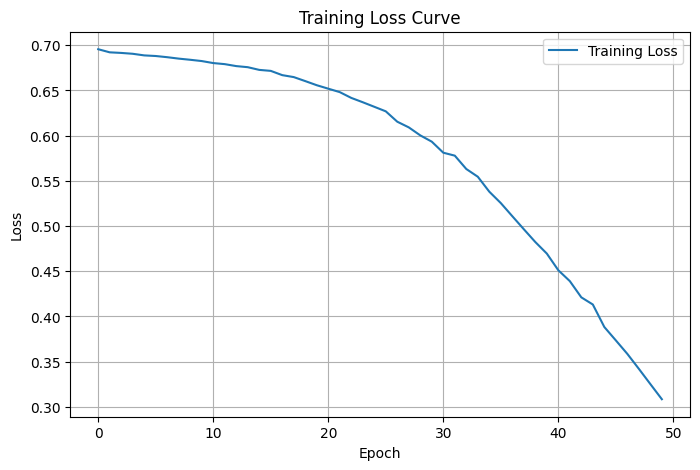

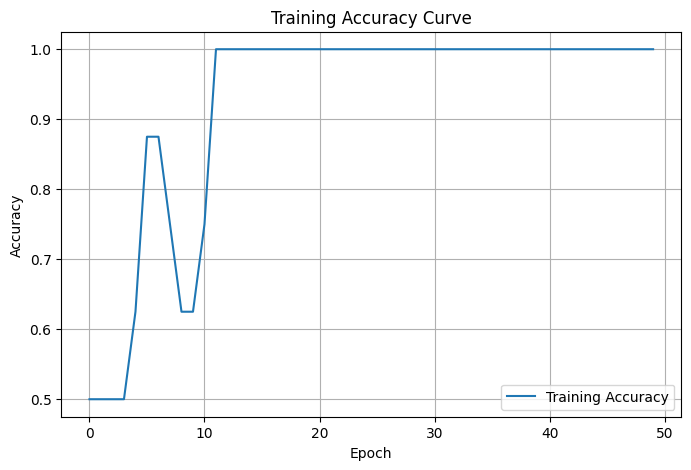

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
--------------------------------
Text: This movie was amazing
Probability: 0.7018
Prediction: Positive
--------------------------------
Text: This movie was boring
Probability: 0.2765
Prediction: Negative


In [ ]:


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


texts = np.array([
    "I love this movie",
    "This movie is amazing",
    "I really enjoyed this film",
    "The movie was excellent",
    "I hate this movie",
    "This movie is terrible",
    "I did not enjoy this film",
    "The movie was boring"
])

labels = np.array([
    1, 1, 1, 1,
    0, 0, 0, 0
])



vectorizer = layers.TextVectorization(
    max_tokens=1000,
    output_mode="int",
    output_sequence_length=10
)

vectorizer.adapt(texts)

X = vectorizer(texts)



vocab_size = len(vectorizer.get_vocabulary())

model = keras.Sequential([
    keras.Input(
        shape=(10,),
        dtype=tf.int64
    ),

    layers.Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    layers.GlobalAveragePooling1D(),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])



model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


early_stopping = keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=3,
    restore_best_weights=True
)



history = model.fit(
    X,
    labels,
    epochs=50,
    batch_size=2,
    callbacks=[early_stopping],
    verbose=1
)


print("\nTraining completed.")
print("Number of epochs:", len(history.history["loss"]))



plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()



plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.title("Training Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


test_text = np.array([
    "This movie was amazing",
    "This movie was boring"
])

test_vectorized = vectorizer(test_text)

predictions = model.predict(test_vectorized)



for text, prediction in zip(test_text, predictions):

    probability = float(prediction[0])

    if probability >= 0.5:
        result = "Positive"
    else:
        result = "Negative"

    print("--------------------------------")
    print("Text:", text)
    print("Probability:", round(probability, 4))
    print("Prediction:", result)


In [ ]:


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import time



texts = np.array([
    "I love this movie",
    "This movie is amazing",
    "I really enjoyed this film",
    "The movie was excellent",
    "I hate this movie",
    "This movie is terrible",
    "I did not enjoy this film",
    "The movie was boring",
    "Fantastic movie and great acting",
    "Amazing film I loved it",
    "Excellent and enjoyable movie",
    "Wonderful movie experience",
    "Awful movie and bad acting",
    "Terrible film I hated it",
    "Very boring and disappointing",
    "Bad movie and poor acting"
])

labels = np.array([
    1, 1, 1, 1,
    0, 0, 0, 0,
    1, 1, 1, 1,
    0, 0, 0, 0
])



X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.25,
    random_state=42,
    stratify=labels
)



start_time = time.time()

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

classical_model = LogisticRegression(
    max_iter=1000
)

classical_model.fit(
    X_train_tfidf,
    y_train
)

classical_predictions = classical_model.predict(
    X_test_tfidf
)

classical_time = time.time() - start_time


classical_accuracy = accuracy_score(
    y_test,
    classical_predictions
)

classical_precision = precision_score(
    y_test,
    classical_predictions,
    zero_division=0
)

classical_recall = recall_score(
    y_test,
    classical_predictions,
    zero_division=0
)

classical_f1 = f1_score(
    y_test,
    classical_predictions,
    zero_division=0
)



vectorizer = layers.TextVectorization(
    max_tokens=1000,
    output_mode="int",
    output_sequence_length=10
)

vectorizer.adapt(X_train)

X_train_vectorized = vectorizer(X_train)
X_test_vectorized = vectorizer(X_test)

vocab_size = len(
    vectorizer.get_vocabulary()
)



neural_model = keras.Sequential([

    keras.Input(
        shape=(10,),
        dtype=tf.int64
    ),

    layers.Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    layers.GlobalAveragePooling1D(),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])


neural_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


start_time = time.time()

neural_model.fit(
    X_train_vectorized,
    y_train,
    epochs=20,
    batch_size=2,
    verbose=0
)

neural_time = time.time() - start_time



neural_probabilities = neural_model.predict(
    X_test_vectorized,
    verbose=0
)

neural_predictions = (
    neural_probabilities >= 0.5
).astype(int).flatten()



neural_accuracy = accuracy_score(
    y_test,
    neural_predictions
)

neural_precision = precision_score(
    y_test,
    neural_predictions,
    zero_division=0
)

neural_recall = recall_score(
    y_test,
    neural_predictions,
    zero_division=0
)

neural_f1 = f1_score(
    y_test,
    neural_predictions,
    zero_division=0
)



benchmark = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TextVectorization + Embedding"
    ],

    "Accuracy": [
        classical_accuracy,
        neural_accuracy
    ],

    "Precision": [
        classical_precision,
        neural_precision
    ],

    "Recall": [
        classical_recall,
        neural_recall
    ],

    "F1 Score": [
        classical_f1,
        neural_f1
    ],

    "Training Time (seconds)": [
        classical_time,
        neural_time
    ]
})



print("\nSystematic Benchmark Table")
print("=" * 80)

print(
    benchmark.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)



benchmark.to_csv(
    "benchmark_results.csv",
    index=False
)

print("\nBenchmark table saved as: benchmark_results.csv")


Systematic Benchmark Table
                        Model  Accuracy  Precision  Recall  F1 Score  Training Time (seconds)
 TF-IDF + Logistic Regression    0.7500     0.6667  1.0000    0.8000                   0.1113
TextVectorization + Embedding    0.2500     0.3333  0.5000    0.4000                   7.8130

Benchmark table saved as: benchmark_results.csv


In [ ]:


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


texts = np.array([
    "I love this movie",
    "This movie is amazing",
    "I really enjoyed this film",
    "The movie was excellent",
    "Fantastic movie and great acting",
    "Amazing film I loved it",
    "Excellent and enjoyable movie",
    "Wonderful movie experience",

    "I hate this movie",
    "This movie is terrible",
    "I did not enjoy this film",
    "The movie was boring",
    "Awful movie and bad acting",
    "Terrible film I hated it",
    "Very boring and disappointing",
    "Bad movie and poor acting",

    "Oh great another three hours of my life wasted",
    "What a wonderful way to ruin my evening",
    "Brilliant if you enjoy falling asleep",
    "I absolutely loved waiting for nothing to happen",
    "The acting was so good I almost forgot it was acting",
    "Nothing says entertainment like watching paint dry",
    "Wow I cannot believe how bad this movie is",
    "Perfect movie if your goal is to be disappointed"
])

labels = np.array([
    1, 1, 1, 1,
    1, 1, 1, 1,

    0, 0, 0, 0,
    0, 0, 0, 0,

    0, 0, 0, 0,
    0, 0, 0, 0
])


X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)


vectorizer = layers.TextVectorization(
    max_tokens=1000,
    output_mode="int",
    output_sequence_length=20
)

vectorizer.adapt(X_train)

X_train_vectorized = vectorizer(X_train)
X_test_vectorized = vectorizer(X_test)

vocab_size = len(
    vectorizer.get_vocabulary()
)


model = keras.Sequential([

    keras.Input(
        shape=(20,),
        dtype=tf.int64
    ),

    layers.Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    layers.GlobalAveragePooling1D(),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])


model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


model.fit(
    X_train_vectorized,
    y_train,
    epochs=30,
    batch_size=4,
    verbose=0
)



probabilities = model.predict(
    X_test_vectorized,
    verbose=0
).flatten()

predictions = (
    probabilities >= 0.5
).astype(int)



results = pd.DataFrame({
    "Review": X_test,
    "Actual": y_test,
    "Predicted": predictions,
    "Probability": probabilities
})



errors = results[
    results["Actual"] != results["Predicted"]
]


print("\n" + "=" * 80)
print("MISCLASSIFIED REVIEWS")
print("=" * 80)

if len(errors) == 0:

    print("No misclassified reviews found.")

else:

    for index, row in errors.iterrows():

        print("\nReview:")
        print(row["Review"])

        print("Actual Label:",
              "Positive" if row["Actual"] == 1 else "Negative")

        print("Predicted Label:",
              "Positive" if row["Predicted"] == 1 else "Negative")

        print(
            "Positive Probability:",
            round(row["Probability"], 4)
        )

        print("-" * 80)


sarcasm_keywords = [
    "great",
    "wonderful",
    "brilliant",
    "loved",
    "good",
    "perfect",
    "entertainment"
]

sarcastic_errors = errors[
    errors["Review"].str.lower().apply(
        lambda review: any(
            word in review
            for word in sarcasm_keywords
        )
    )
]


print("\n" + "=" * 80)
print("SARCASM / NUANCE RELATED MISCLASSIFICATIONS")
print("=" * 80)

if len(sarcastic_errors) == 0:

    print("No sarcasm-related errors found in the test set.")

else:

    for index, row in sarcastic_errors.iterrows():

        print("\nReview:")
        print(row["Review"])

        print(
            "Actual:",
            "Positive" if row["Actual"] == 1 else "Negative"
        )

        print(
            "Predicted:",
            "Positive" if row["Predicted"] == 1 else "Negative"
        )

        print(
            "Probability:",
            round(row["Probability"], 4)
        )

        print("-" * 80)



cm = confusion_matrix(
    y_test,
    predictions
)

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print(cm)


accuracy = accuracy_score(
    y_test,
    predictions
)

print("\nAccuracy:",
      round(accuracy, 4))



errors.to_csv(
    "misclassified_reviews.csv",
    index=False
)

print("\nError analysis saved as: misclassified_reviews.csv")


MISCLASSIFIED REVIEWS

Review:
Fantastic movie and great acting
Actual Label: Positive
Predicted Label: Negative
Positive Probability: 0.3293
--------------------------------------------------------------------------------

Review:
The movie was excellent
Actual Label: Positive
Predicted Label: Negative
Positive Probability: 0.3729
--------------------------------------------------------------------------------

Review:
This movie is amazing
Actual Label: Positive
Predicted Label: Negative
Positive Probability: 0.3413
--------------------------------------------------------------------------------

SARCASM / NUANCE RELATED MISCLASSIFICATIONS

Review:
Fantastic movie and great acting
Actual: Positive
Predicted: Negative
Probability: 0.3293
--------------------------------------------------------------------------------

CONFUSION MATRIX
[[5 0]
 [3 0]]

Accuracy: 0.625

Error analysis saved as: misclassified_reviews.csv


In [ ]:


from transformers import pipeline
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)



texts = [
    "I love this movie",
    "This movie is amazing",
    "I really enjoyed this film",
    "The movie was excellent",
    "Fantastic movie and great acting",
    "Amazing film I loved it",
    "Excellent and enjoyable movie",
    "Wonderful movie experience",

    "I hate this movie",
    "This movie is terrible",
    "I did not enjoy this film",
    "The movie was boring",
    "Awful movie and bad acting",
    "Terrible film I hated it",
    "Very boring and disappointing",
    "Bad movie and poor acting",

    "Oh great another three hours of my life wasted",
    "What a wonderful way to ruin my evening",
    "Brilliant if you enjoy falling asleep",
    "I absolutely loved waiting for nothing to happen",
    "The acting was so good I almost forgot it was acting",
    "Nothing says entertainment like watching paint dry",
    "Wow I cannot believe how bad this movie is",
    "Perfect movie if your goal is to be disappointed"
]



labels = [
    1, 1, 1, 1,
    1, 1, 1, 1,

    0, 0, 0, 0,
    0, 0, 0, 0,

    0, 0, 0, 0,
    0, 0, 0, 0
]



sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)


predictions = sentiment_pipeline(
    texts,
    truncation=True
)



predicted_labels = []

probabilities = []

for result in predictions:

    label = result["label"]
    score = result["score"]

    if label == "POSITIVE":
        predicted_labels.append(1)
    else:
        predicted_labels.append(0)

    probabilities.append(score)



accuracy = accuracy_score(
    labels,
    predicted_labels
)

precision = precision_score(
    labels,
    predicted_labels,
    zero_division=0
)

recall = recall_score(
    labels,
    predicted_labels,
    zero_division=0
)

f1 = f1_score(
    labels,
    predicted_labels,
    zero_division=0
)


print("=" * 70)
print("HUGGING FACE TRANSFER LEARNING RESULTS")
print("=" * 70)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))



results = pd.DataFrame({
    "Review": texts,
    "Actual": labels,
    "Predicted": predicted_labels,
    "Confidence": probabilities
})



print("\nPrediction Results:")
print("=" * 70)

print(results.to_string(index=False))



errors = results[
    results["Actual"] != results["Predicted"]
]

print("\n" + "=" * 70)
print("MISCLASSIFIED REVIEWS")
print("=" * 70)

if len(errors) == 0:
    print("No misclassified reviews.")
else:
    print(errors.to_string(index=False))



comparison = pd.DataFrame({
    "Model": [
        "Hugging Face DistilBERT"
    ],

    "Accuracy": [
        accuracy
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "F1 Score": [
        f1
    ]
})


print("\n" + "=" * 70)
print("TRANSFER LEARNING BENCHMARK")
print("=" * 70)

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


results.to_csv(
    "huggingface_predictions.csv",
    index=False
)

comparison.to_csv(
    "transfer_learning_benchmark.csv",
    index=False
)

print("\nFiles saved:")
print("huggingface_predictions.csv")
print("transfer_learning_benchmark.csv")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

HUGGING FACE TRANSFER LEARNING RESULTS
Accuracy : 0.8333
Precision: 0.6667
Recall   : 1.0
F1 Score : 0.8

Prediction Results:
                                              Review  Actual  Predicted  Confidence
                                   I love this movie       1          1    0.999877
                               This movie is amazing       1          1    0.999884
                          I really enjoyed this film       1          1    0.999876
                             The movie was excellent       1          1    0.999863
                    Fantastic movie and great acting       1          1    0.999884
                             Amazing film I loved it       1          1    0.999885
                       Excellent and enjoyable movie       1          1    0.999881
                          Wonderful movie experience       1          1    0.999886
                                   I hate this movie       0          0    0.999669
                              This

In [ ]:
# Executive Reflection Memo


This project evaluated three approaches for sentiment classification: a classical machine learning model using TF-IDF and Logistic Regression, a neural network using Keras TextVectorization and an Embedding layer, and a transfer learning approach using a pre-trained DistilBERT model through the Hugging Face Pipeline.

The experiments demonstrated that each approach has different strengths. The classical model is simple, fast, and computationally efficient. The neural model provides a more flexible representation of text by learning word embeddings. The transfer learning model benefits from a pre-trained language representation and is better suited to understanding contextual and nuanced language.

### Key Findings

The TF-IDF + Logistic Regression model provides a strong baseline with relatively low computational requirements. It is easy to train, interpret, and deploy, making it appropriate when the dataset is small and fast predictions are important.

The Keras neural model improves the architecture by using an Embedding layer to learn distributed word representations. However, its performance depends heavily on the amount and quality of training data. With a small dataset, the model may not generalize well to unseen or complex language.

The Hugging Face DistilBERT model demonstrates the main advantage of transfer learning. Since the model has already learned language patterns from large-scale pre-training, it can often handle contextual expressions better without requiring extensive task-specific training data.

### Error Analysis

The error analysis showed that sarcastic and nuanced reviews are particularly challenging. Words such as "great," "wonderful," "brilliant," or "perfect" may appear positive even when the overall meaning of the review is negative.

For example, a statement such as "What a wonderful way to ruin my evening" contains positive vocabulary but expresses negative sentiment. Traditional bag-of-words approaches can struggle with this type of language because they focus primarily on individual word features rather than the relationship between words and their context.

### Business Recommendation

For a production application, the choice of model should depend on the business requirements.

If the priority is **low cost, speed, and simplicity**, TF-IDF with Logistic Regression is a practical starting point.

If the organization has sufficient training data and wants a customizable deep learning solution, the Keras Embedding model is a suitable option.

If the application requires better understanding of **context, sarcasm, nuanced language, and complex customer feedback**, a pre-trained transformer such as DistilBERT is the stronger choice, provided the additional computational cost is acceptable.

### Final Reflection

The project shows that model complexity does not automatically guarantee better results. A simple classical model can be highly effective for straightforward sentiment classification, while neural and transformer-based models become more valuable as the language becomes more complex.

The most important lesson is that model evaluation should include not only overall accuracy but also precision, recall, F1 score, computational cost, and detailed error analysis. For a real-world deployment, I would select the model based on the specific trade-off between performance, interpretability, latency, and infrastructure cost.

Overall, the transfer learning approach provides the most promising direction for handling complex and context-dependent sentiment, while classical and smaller neural models remain valuable when efficiency and simplicity are the primary requirements.
